# Problem 12.2: Identifying Good System Administrators
A management consultant is studying the roles played by experience and training in a system administrator's ability to complete a set of tasks in a specified amount of time. In particular, she is interested in discriminating between administrators who are able to complete given tasks within a specified time and those who are not. Data are collected on the performance of 75 randomly selected administrators. They are stored in the dataset  _SystemAdministrators.csv_.

Using these data, the consultant performs a discriminant analysis. The variable Experience measures months of full time system administrator experience, while Training measures number of relevant training credits. The dependent variable Completed is either _Yes_ or _No_, according to whether or not the administrator completed the tasks.

In [1]:
!python --version

Python 3.13.5


In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
import matplotlib.pylab as plt
import mlba

%matplotlib inline

In [3]:
df = mlba.load_data('SystemAdministrators.csv')
df.head()

,Experience,Training,Completed task
0,10.9,4,Yes
1,9.9,4,Yes
2,10.4,6,Yes
3,13.7,6,Yes
4,9.4,8,Yes


__12.2.a__
Create a scatter plot of Experience vs. Training using color or symbol to differentiate administrators who completed the tasks from those who did not complete them. See if you can identify a line that separates the two classes with minimum misclassification.

#My attempt
plt.scatter(df['Experience'], df['Training'], cmap=df['Completed task'])
plt.title('Experience vs Training based on those who completed tasks')
plt.xlabel('Experience')
plt.ylabel('Training')

C:\Users\samsc\AppData\Roaming\Python\Python313\site-packages\pandas\plotting\_matplotlib\core.py:1351: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  scatter = ax.scatter(
C:\Users\samsc\AppData\Roaming\Python\Python313\site-packages\pandas\plotting\_matplotlib\core.py:1351: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  scatter = ax.scatter(


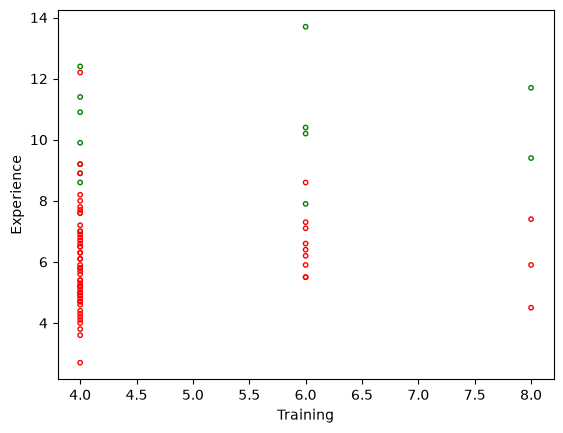

In [11]:
ax = df[df['Completed task'] == 'Yes'].plot.scatter(x='Training', y='Experience', c='none', facecolors='none', edgecolors='green', s=10)

df[df["Completed task"] == "No"].plot.scatter(
    x="Training", y="Experience", c="none", facecolors="none", edgecolors="red", s=10, ax=ax)

plt.show()

Both training and experience contribute and have a positive correlation with each other in termns of if the task will be completed.

__12.2.b__
Run a discriminant analysis with both predictors using the entire dataset as training data.  Among those who completed the tasks, what is the percentage of administrators who are classified incorrectly as failing to complete the tasks?

In [14]:
predictors = ['Training', 'Experience']
outcome = 'Completed task'

da = LinearDiscriminantAnalysis()
da.fit(df[predictors], df[outcome])
mlba.classificationSummary(y_true=df[outcome], y_pred=da.predict(df[predictors]))

Confusion Matrix (Accuracy 0.9067)

       Prediction
Actual  No Yes
    No  58   2
   Yes   5  10


__12.2.c__
Compute the decision score for an administrator with 4 months of experience and six credits of training. Based on this score, how would you classify this administrator?

In [22]:
new_admin = pd.DataFrame([{'Experience': 4, 'Training': 6}])
da.predict(new_admin[predictors]) #The model would classify this admin as No, not completing the task

array(['No'], dtype='<U3')

__12.2.d__
How much experience must be accumulated by an administrator with four training credits before his or her estimated probability of completing the tasks exceeds 0.5?

In [31]:
for experience in range(3,14):
    admin = pd.DataFrame([{'Training': 4.0, 'Experience': experience}])
    print(f"Experience: {experience}, {da.predict_proba(admin[predictors])[0][1]:.3f}")
    if da.predict_proba(admin[predictors])[0][1] > 0.5:
        break

Experience: 3, 0.000
Experience: 4, 0.001
Experience: 5, 0.003
Experience: 6, 0.012
Experience: 7, 0.049
Experience: 8, 0.187
Experience: 9, 0.503


__12.2.e__
Compare the classification accuracy of this model to that resulting from a logistic regression with cutoff 0.5.

In [34]:
lr = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
lr.fit(df[predictors], df[outcome])
mlba.classificationSummary(y_true=df[outcome], y_pred=lr.predict(df[predictors]))

Confusion Matrix (Accuracy 0.9067)

       Prediction
Actual  No Yes
    No  58   2
   Yes   5  10


C:\Users\samsc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
